# [10 k -> extact aspect, check index, get window size -> snippets, aspect_id]

In [240]:
import pandas as pd
import ast 

df_all = pd.read_csv("/Users/lorenaraichle/Developer/ABSA/PyABSA/results/ate_batch_results_10_000.csv")
df_all.shape

(10000, 14)

In [241]:
df_all.columns

Index(['company_id', 'review_id', 'name', 'industry', 'review', 'likes',
       'rating', 'posted_at', 'token_count', 'too_long', 'aspect', 'sentiment',
       'confidence', 'position'],
      dtype='object')

In [242]:
df_all

,company_id,review_id,name,industry,review,likes,rating,posted_at,token_count,too_long,aspect,sentiment,confidence,position
0,585827,6424995,Riwa Gastro AG,Restaurant,Leckeres Eis und netter Service!,0,4.0,2023-04-22 15:50:01.416,11,False,"['Eis', 'Service']","['Positive', 'Positive']","[0.9981, 0.9982]","[[1], [4]]"
1,585827,6424999,Riwa Gastro AG,Restaurant,"Try it! The first impression is deceiving, loo...",1,5.0,2019-02-09 19:53:26.000,118,False,[],[],[],[]
2,585827,6425000,Riwa Gastro AG,Restaurant,Immer alles perfekt. Danke,0,5.0,2023-04-16 13:18:36.731,9,False,[],[],[],[]
3,585827,6425004,Riwa Gastro AG,Restaurant,Feine Desserts❤️,0,5.0,2023-04-11 06:45:40.392,9,False,['Desserts'],['Positive'],[0.9656],[[1]]
4,585827,6425006,Riwa Gastro AG,Restaurant,5 Sterne absolut verdient!,0,5.0,2023-04-10 14:29:48.634,9,False,[],[],[],[]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,207535,6444223,Dürr Reinigungssysteme GmbH,Cleaners,"Die Beratung von Jakob Dürr, ist kompetent und...",0,5.0,2019-06-22 20:29:41.977,34,False,"['Beratung', 'Service']","['Positive', 'Positive']","[0.9984, 0.9966]","[[1], [17]]"
9996,491078,6444229,Naef Industries GmbH,NaN,"top service, schnell und zuverlässig. gerne wi...",0,5.0,2025-05-19 12:37:35.631,16,False,['service'],['Positive'],[0.9985],[[1]]
9997,491078,6444230,Naef Industries GmbH,NaN,Vielen Dank für die schnelle Unterstützung & t...,0,5.0,2025-05-18 09:12:02.324,24,False,"['Unterstützung', 'Arbeit']","['Positive', 'Positive']","[0.9985, 0.9985]","[[5], [8]]"
9998,491078,6444231,Naef Industries GmbH,NaN,Super Arbeit komme gerne wieder.,0,5.0,2025-02-01 12:41:43.225,9,False,['Arbeit'],['Positive'],[0.998],[[1]]


In [98]:
import pandas as pd
import ast
from tqdm import tqdm
from sentence_transformers import SentenceTransformer
from nltk.tokenize import word_tokenize
import nltk
nltk.download('punkt') 

import unicodedata
import re

import unicodedata
import re

def normalize_for_matching(text):
    # Convert to ASCII (removes accents and curly quotes)
    text = unicodedata.normalize("NFKD", text).encode("ASCII", "ignore").decode("utf-8")

    # Replace & and / with space to split tokens better
    text = text.replace("&", " ").replace("/", " ")

    # Remove remaining punctuation (quotes, dashes, etc.)
    text = re.sub(r"[^\w\s]", "", text)

    # Collapse multiple spaces
    text = re.sub(r"\s+", " ", text)

    return text.strip().lower()



def tokenize(text):
    return word_tokenize(text)

for col in ['aspect', 'sentiment', 'confidence', 'position']:
    df_all[col] = df_all[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

tqdm.pandas()

unmatched_aspect_count = 0

def correct_position(text, aspect, initial_pos, review_id):
    global unmatched_aspect_count

    # Normalize aspect and review
    aspect_norm = normalize_for_matching(aspect)
    review_text_norm = normalize_for_matching(text)
    aspect_fused = aspect_norm.replace(" ", "")

    # Global text-level matching
    if aspect_norm not in review_text_norm and aspect_fused not in review_text_norm.replace(" ", ""):
        print(f"[WARNING] Aspect '{aspect}' not found in review_id {review_id}")
        unmatched_aspect_count += 1
        return None

    # Token-based matching
    tokens = tokenize(text)
    token_sequence = [normalize_for_matching(t) for t in tokens]
    aspect_tokens = aspect_norm.split()
    candidate_positions = []

    for i in range(len(token_sequence)):
        joined_span = " ".join(token_sequence[i:i+len(aspect_tokens)+2])
        fused_span = joined_span.replace(" ", "")

        if aspect_norm in joined_span or aspect_fused in fused_span:
            candidate_positions.append(i)

    # Fallback: single-token match
    if not candidate_positions:
        for i, t in enumerate(token_sequence):
            if aspect_norm in t or aspect_fused in t.replace(" ", ""):
                candidate_positions.append(i)

    # Still nothing? Final warning.
    if not candidate_positions:
        print(f"[WARNING] Aspect '{aspect}' matched in review text but no span found in tokens (review_id {review_id})")
        unmatched_aspect_count += 1
        return None

    # Return closest match to model's position
    closest_pos = min(candidate_positions, key=lambda x: abs(x - initial_pos))
    return closest_pos







def extract_snippet(text, aspect, pos, review_id, window=5):
    corrected_pos = correct_position(text, aspect, pos, review_id)
    if corrected_pos is None:
        return ""

    tokens = tokenize(text)
    start = max(corrected_pos - window, 0)
    end = min(corrected_pos + window + 1, len(tokens))
    return " ".join(tokens[start:end])



def safe_get_pos(pos):
    if isinstance(pos, list) and pos:
        return int(pos[0])
    try:
        return int(pos)
    except Exception:
        return None

window_sizes = [1, 2, 4]

records = []
for _, row in df_all.iterrows():
    for asp, sent, conf, pos in zip(row['aspect'], row['sentiment'], row['confidence'], row['position']):
        position = safe_get_pos(pos)
        if position is None:
            continue

        entry = {
            "review_id": row['review_id'],
            "review": row['review'],
            "aspect": asp,
            "sentiment": sent,
            "confidence": float(conf),
            "position": position
        }

        for win in window_sizes:
            entry[f"snippet_{win}"] = extract_snippet(row['review'], asp, position, row['review_id'], window=win)


        records.append(entry)


df_multi_snippets = pd.DataFrame(records)

print(f"Total unmatched aspects: {unmatched_aspect_count}")

for win in window_sizes:
    col = f"snippet_{win}"
    emb_col = f"embedding_{win}"
    print(f"Encoding {col}...")
    df_multi_snippets[emb_col] = df_multi_snippets[col].progress_apply(lambda x: model.encode(x).tolist())


[nltk_data] Downloading package punkt to
[nltk_data]     /Users/lorenaraichle/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Total unmatched aspects: 0
Encoding snippet_1...


100%|██████████| 19502/19502 [03:20<00:00, 97.36it/s] 


Encoding snippet_2...


100%|██████████| 19502/19502 [03:20<00:00, 97.17it/s] 


Encoding snippet_4...


100%|██████████| 19502/19502 [03:21<00:00, 96.94it/s] 


In [99]:
df_multi_snippets.shape

(19502, 12)

In [100]:
# Add aspect number within each review
df_multi_snippets['aspect_number'] = df_multi_snippets.groupby('review_id').cumcount() + 1

# Create unique aspect ID like 6425007_1, 6425007_2, ...
df_multi_snippets['aspect_id'] = (
    df_multi_snippets['review_id'].astype(str) + '_' + df_multi_snippets['aspect_number'].astype(str)
)

df_multi_snippets.shape


(19502, 14)

In [101]:
df_multi_snippets["review_id"].nunique()

7314

In [102]:
df_multi_snippets["aspect_id"].nunique()

19502

In [103]:
cols = df_multi_snippets.columns.tolist()
aspect_index = cols.index('aspect')
reordered = (
    cols[:aspect_index + 1] +
    ['aspect_id'] +
    [col for col in cols if col not in ['aspect_id'] and col not in cols[:aspect_index + 1]]
)
df_multi_snippets = df_multi_snippets[reordered]


In [104]:
df_multi_snippets

,review_id,review,aspect,aspect_id,sentiment,confidence,position,snippet_1,snippet_2,snippet_4,embedding_1,embedding_2,embedding_4,aspect_number
0,6424995,Leckeres Eis und netter Service!,Eis,6424995_1,Positive,0.9981,1,Leckeres Eis und,Leckeres Eis und netter,Leckeres Eis und netter Service !,"[-0.1283980906009674, -0.03624747321009636, 0....","[-0.10986431688070297, -0.040036339312791824, ...","[-0.16587071120738983, -0.20027723908424377, 0...",1
1,6424995,Leckeres Eis und netter Service!,Service,6424995_2,Positive,0.9982,4,netter Service !,und netter Service !,Leckeres Eis und netter Service !,"[-0.06051437184214592, -0.22395312786102295, -...","[-0.06176280975341797, -0.13433699309825897, 0...","[-0.16587071120738983, -0.20027723908424377, 0...",2
2,6425004,Feine Desserts❤️,Desserts,6425004_1,Positive,0.9656,1,Feine Desserts❤️,Feine Desserts❤️,Feine Desserts❤️,"[-0.238739013671875, -0.2715420126914978, 0.36...","[-0.238739013671875, -0.2715420126914978, 0.36...","[-0.238739013671875, -0.2715420126914978, 0.36...",1
3,6425007,Sehr schönes Ausflugsrestaurant mit fantastisc...,Aussicht,6425007_1,Positive,0.9985,5,fantastischer Aussicht .,mit fantastischer Aussicht . Sehr,schönes Ausflugsrestaurant mit fantastischer A...,"[0.23287248611450195, -0.03214649483561516, -0...","[0.17862626910209656, -0.019400477409362793, -...","[0.4620816707611084, -0.16975641250610352, -0....",1
4,6425007,Sehr schönes Ausflugsrestaurant mit fantastisc...,Personal,6425007_2,Positive,0.9981,9,"freundliches Personal ,","Sehr freundliches Personal , schnelle","Aussicht . Sehr freundliches Personal , schnel...","[-0.14340147376060486, 0.09469904005527496, -0...","[-0.028471510857343674, -0.0008600931614637375...","[-0.01213036011904478, -0.0051398673094809055,...",2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19497,6444230,Vielen Dank für die schnelle Unterstützung & t...,Arbeit,6444230_2,Positive,0.9985,8,top Arbeit .,& top Arbeit . Ich,schnelle Unterstützung & top Arbeit . Ich komm...,"[-0.018575815483927727, 0.03293238952755928, -...","[0.028238318860530853, 0.059422727674245834, 0...","[-0.11923038959503174, -0.08902967721223831, -...",2
19498,6444231,Super Arbeit komme gerne wieder.,Arbeit,6444231_1,Positive,0.9980,1,Super Arbeit komme,Super Arbeit komme gerne,Super Arbeit komme gerne wieder .,"[0.030481314286589622, -0.026449251919984818, ...","[0.10321161895990372, 0.01846766658127308, -0....","[0.10308770090341568, -0.0805082842707634, 0.0...",1
19499,6444232,"Danke für die schnelle Hilfe, die gute Arbeit ...",Arbeit,6444232_1,Positive,0.9986,8,gute Arbeit und,die gute Arbeit und die,"Hilfe , die gute Arbeit und die freundliche Be...","[0.009423285722732544, -0.07107557356357574, -...","[-0.03040573187172413, -0.04432479664683342, -...","[-0.017541276291012764, -0.1783563196659088, 0...",1
19500,6444232,"Danke für die schnelle Hilfe, die gute Arbeit ...",Bedienung,6444232_2,Positive,0.9986,12,freundliche Bedienung .,die freundliche Bedienung . Top,Arbeit und die freundliche Bedienung . Top Ser...,"[0.04003254696726799, 0.008472288027405739, 0....","[0.008016233332455158, 0.03156857192516327, -0...","[-0.06527985632419586, -0.2157687246799469, 0....",2


In [105]:
df_multi_snippets.to_json("/Users/lorenaraichle/Developer/ABSA/PyABSA/results/snippets_with_embeddings_23184.json", orient="records", lines=True)


# [upsert context window data]

In [106]:

import psycopg2
import os
from psycopg2.extras import execute_batch
import dotenv

from dotenv import load_dotenv
import ast
import json

load_dotenv()

for col in ['embedding_1', 'embedding_2', 'embedding_4']:
    df_multi_snippets[col] = df_multi_snippets[col].apply(lambda x: json.loads(x) if isinstance(x, str) else x)


conn_params = {
    "host": os.getenv("DB_HOST"),
    "port": os.getenv("DB_PORT"),
    "database": os.getenv("DB_NAME"),
    "user": os.getenv("DB_USER"),
    "password": os.getenv("DB_PASSWORD")
}


insert_sql = """
INSERT INTO aspect_sentiment_results (
    review_id, aspect, sentiment, confidence, position,
    snippet_1, snippet_2, snippet_4,
    embedding_1, embedding_2, embedding_4,
    aspect_id
)
VALUES (%s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s)
ON CONFLICT (aspect_id) DO UPDATE SET
    sentiment = EXCLUDED.sentiment,
    confidence = EXCLUDED.confidence,
    position = EXCLUDED.position,
    snippet_1 = EXCLUDED.snippet_1,
    snippet_2 = EXCLUDED.snippet_2,
    snippet_4 = EXCLUDED.snippet_4,
    embedding_1 = EXCLUDED.embedding_1,
    embedding_2 = EXCLUDED.embedding_2,
    embedding_4 = EXCLUDED.embedding_4;
"""


try:
    conn = psycopg2.connect(**conn_params)
    cur = conn.cursor()

    execute_batch(cur, insert_sql, [
    (
        row['review_id'], row['aspect'], row['sentiment'],
        float(row['confidence']), int(row['position']),
        row.get('snippet_1'), row.get('snippet_2'), row.get('snippet_4'),
        row['embedding_1'], row['embedding_2'], row['embedding_4'],
        row['aspect_id']
    )
    for _, row in df_multi_snippets.iterrows()
    ])

    conn.commit()
    print("Insert successful!")

except Exception as e:
    print("Insert failed:", e)

finally:
    if 'conn' in locals():
        conn.close()


Insert successful!


 # ! hybrid search test "preis"

### 1. all results ordered by distance -> determine cosine distance threshold

In [ ]:
query_text_sauberkeit = (
    "Sauberkeit: Erwähnung von sauber, dreckig, schmutzig, hygienisch, unhygienisch, "
    "gepflegt, ungepflegt, rein, unrein, ordentlich, unordentlich, Müll, Gestank, Geruch, "
    "saubere Umgebung, schmutzige Umgebung."
)

query_text_akustik = (
    "Akustik: Erwähnung von laut, leise, Geräuschpegel, Lärm, Stille, ruhige Atmosphäre, "
    "laute Umgebung, hallend, dumpf, klarer Klang, schlechter Klang, Musiklautstärke, "
    "Hintergrundgeräusche."
)

query_text_barrierefreiheit = (
    "Barrierefreiheit: Erwähnung von barrierefrei, Rollstuhlzugang, Aufzug vorhanden, "
    "kein Aufzug, Stufen, Treppen, behindertengerecht, leicht zugänglich, schwer zugänglich, "
    "für Menschen mit Behinderung geeignet, Zugang für Rollstuhlfahrer, barrierearme Umgebung, Rollstuhlfahrer"
)

query_text_erreichbarkeit = (
    "Erreichbarkeit: Erwähnung von gut erreichbar, schwer erreichbar, mit öffentlichen "
    "Verkehrsmitteln erreichbar, Parkplatz, Parkmöglichkeiten, Anfahrt, Lage, nahe gelegen, "
    "weit entfernt, Haltestelle in der Nähe, Verkehrsanbindung, Wegbeschreibung."
)


query_text_kaffee = (
    "Kaffee: Erwähnung von Kaffee, Espresso, Cappuccino, Latte Macchiato, Kaffeegeschmack, "
    "Kaffeebohnen, frisch gebrüht, bitter, mild, Kaffeequalität, Kaffeehaus, Barista, "
    "guter Kaffee, schlechter Kaffee, Kaffeetasse, Koffeingehalt."
)


### example 
query_text_preis = (
    "Preis: Erwähnung des Preises, der Kosten, ob etwas teuer oder günstig war oder gratis, "
    "Preis-Leistungs-Verhältnis, ob jemand zu viel bezahlt hat, ob es sich gelohnt hat, "
    "überteuert, preiswert, billig, angemessen, nicht wert, günstig."
)


In [182]:
import psycopg2
import os
import pandas as pd
from sentence_transformers import SentenceTransformer
from dotenv import load_dotenv

load_dotenv()

model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

# TODO: update query text topic
vector = model.encode(query_text_preis)
vector_str = str(vector.tolist())   

sql = f"""
SELECT review_id, aspect, aspect_id, sentiment, confidence, snippet_4,
       embedding_4  <=> '{vector_str}'::vector AS distance
FROM aspect_sentiment_results
ORDER BY distance;

"""

conn = psycopg2.connect(
    host=os.getenv("DB_HOST"),
    port=os.getenv("DB_PORT"),
    dbname=os.getenv("DB_NAME"),
    user=os.getenv("DB_USER"),
    password=os.getenv("DB_PASSWORD"),
)

with conn.cursor() as cur:
    cur.execute(sql)
    rows = cur.fetchall()
    colnames = [desc[0] for desc in cur.description]

conn.close()

df_results = pd.DataFrame(rows, columns=colnames)

df_results


<class 'numpy.ndarray'>
384
[-0.01547646  0.16977723  0.00539682  0.04011681 -0.12752247]
[-0.015476461499929428, 0.16977722942829132, 0.005396821070462465, 0.04011680930


,review_id,aspect,aspect_id,sentiment,confidence,snippet_4,distance
0,6438665,Preis,6438665_1,Positive,0.4521,in Baumwipfelhöhe ! Der Preis ist zwar etwas ``,0.341004
1,6428525,Preis,6428525_3,Positive,0.9825,toll und zum fairen Preis,0.344057
2,6428992,Preisleistung,6428992_1,Positive,0.9973,Lecker und Preisleistung stimmt,0.356882
3,6426579,Preis,6426579_2,Positive,0.8429,. Da stimmt das Preis Leistunngsverhältnis . N...,0.357340
4,6434676,Preise,6434676_4,Negative,0.9920,Schluss auch nicht . Preise sind eher gehoben für,0.362759
...,...,...,...,...,...,...,...
19497,6435047,Fenster,6435047_4,Positive,0.9940,erholsamen Schlaf . Die Fenster sind schalldic...,1.125106
19498,6435047,Fenster,6435047_11,Positive,0.9940,erholsamen Schlaf . Die Fenster sind schalldic...,1.125106
19499,6431832,Küche,6431832_5,Positive,0.9978,Gemüsegarten für die feine Küche und viele Blu...,1.130822
19500,6431832,Küche,6431832_11,Positive,0.9978,Gemüsegarten für die feine Küche und viele Blu...,1.130822


- all results ordered 

In [183]:
df_results.shape

(19502, 7)

In [184]:
df_results.describe()

,review_id,confidence,distance
count,1.950200e+04,19502.000000,19502.000000
mean,6.433429e+06,0.964683,0.896891
std,4.599518e+03,0.093977,0.089216
min,6.424995e+06,0.341000,0.341004
25%,6.429868e+06,0.989700,0.864283
50%,6.433290e+06,0.997500,0.910864
75%,6.436888e+06,0.998300,0.950202
max,6.444232e+06,0.999000,1.146037


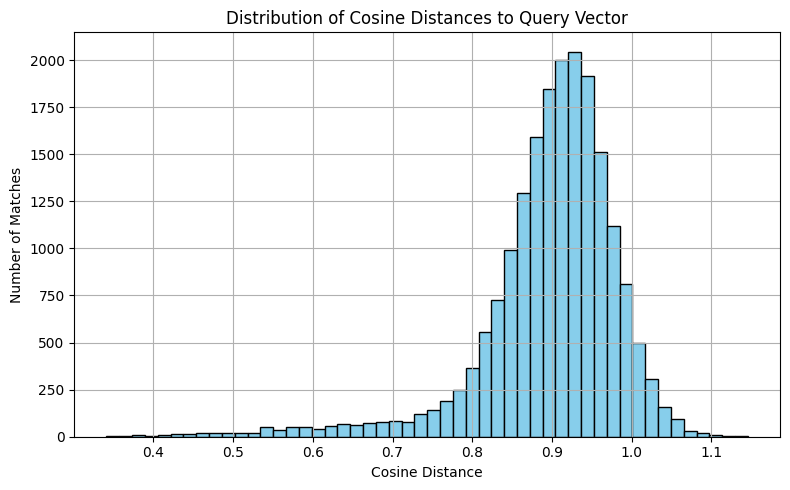

In [185]:
import matplotlib.pyplot as plt

# Ensure you have a 'distance' column
if 'distance' in df_results.columns:
    plt.figure(figsize=(8, 5))
    plt.hist(df_results['distance'], bins=50, color='skyblue', edgecolor='black')
    plt.title("Distribution of Cosine Distances to Query Vector")
    plt.xlabel("Cosine Distance")
    plt.ylabel("Number of Matches")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("Distance column not found in DataFrame.")


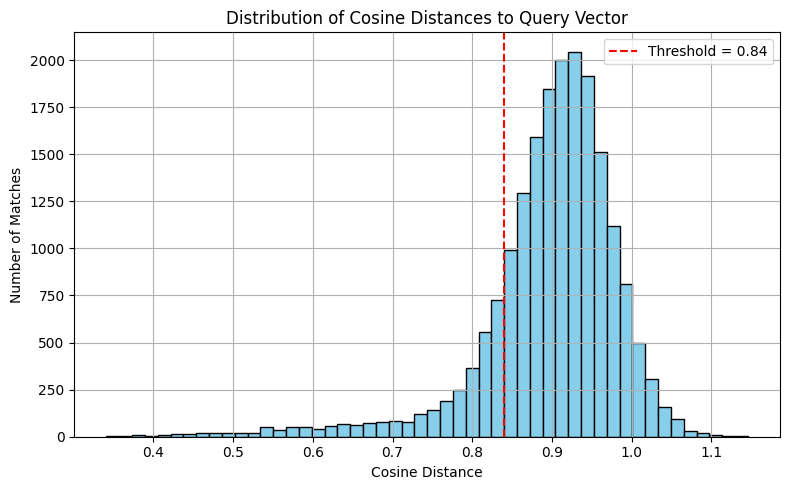

In [186]:
plt.figure(figsize=(8, 5))
plt.hist(df_results['distance'], bins=50, color='skyblue', edgecolor='black')
plt.axvline(0.84, color='red', linestyle='--', label='Threshold = 0.84')
plt.title("Distribution of Cosine Distances to Query Vector")
plt.xlabel("Cosine Distance")
plt.ylabel("Number of Matches")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# elbow method to determine 0.84 threshold

In [187]:
import psycopg2
import os
import pandas as pd
from sentence_transformers import SentenceTransformer
from dotenv import load_dotenv

load_dotenv()

model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
query_text = (
    "Preis: Erwähnung des Preises, der Kosten, ob etwas teuer oder günstig war oder gratis, "
    "Preis-Leistungs-Verhältnis, ob jemand zu viel bezahlt hat, ob es sich gelohnt hat, "
    "überteuert, preiswert, billig, angemessen, nicht wert, günstig."
)

vector = model.encode(query_text)
vector_str = str(vector.tolist())

print(type(vector))            # Should be numpy.ndarray or list
print(len(vector))             # Should be 384
print(vector[:5])              # First few values
print(vector_str[:80])         # First few characters of the string

sql = f"""
SELECT review_id, aspect, aspect_id, sentiment, confidence, snippet_4,
       embedding_4  <=> '{vector_str}'::vector AS distance
FROM aspect_sentiment_results
WHERE embedding_4 <=> '{vector_str}'::vector < 0.84
OR LOWER(aspect) LIKE '%preis%'
ORDER BY distance;

"""

conn = psycopg2.connect(
    host=os.getenv("DB_HOST"),
    port=os.getenv("DB_PORT"),
    dbname=os.getenv("DB_NAME"),
    user=os.getenv("DB_USER"),
    password=os.getenv("DB_PASSWORD"),
)

with conn.cursor() as cur:
    cur.execute(sql)
    rows = cur.fetchall()
    colnames = [desc[0] for desc in cur.description]

conn.close()

df_thresh = pd.DataFrame(rows, columns=colnames)

df_thresh


<class 'numpy.ndarray'>
384
[-0.01547646  0.16977723  0.00539682  0.04011681 -0.12752247]
[-0.015476461499929428, 0.16977722942829132, 0.005396821070462465, 0.04011680930


,review_id,aspect,aspect_id,sentiment,confidence,snippet_4,distance
0,6438665,Preis,6438665_1,Positive,0.4521,in Baumwipfelhöhe ! Der Preis ist zwar etwas ``,0.341004
1,6428525,Preis,6428525_3,Positive,0.9825,toll und zum fairen Preis,0.344057
2,6428992,Preisleistung,6428992_1,Positive,0.9973,Lecker und Preisleistung stimmt,0.356882
3,6426579,Preis,6426579_2,Positive,0.8429,. Da stimmt das Preis Leistunngsverhältnis . N...,0.357340
4,6434676,Preise,6434676_4,Negative,0.9920,Schluss auch nicht . Preise sind eher gehoben für,0.362759
...,...,...,...,...,...,...,...
3247,6440470,Eintrittspreise,6440470_2,Negative,0.8667,die Bäume aber die Eintrittspreise sind nicht ...,0.904123
3248,6435591,preise,6435591_4,Positive,0.9976,schöne Zimmer . Gute preise,0.916868
3249,6439643,PREISE,6439643_1,Positive,0.9704,der Spass vorbei . PREISE RUNTER ! ! !,0.929228
3250,6439612,Eintrittspreise,6439612_1,Neutral,0.4508,es ok . Die Eintrittspreise sind mit 15 Franken,0.947726


In [188]:
df_thresh.shape

(3252, 7)

In [189]:
df_thresh["review_id"].nunique()

2143

### -> out of 10 k entries -> 3 k price aspects in 2000 review_ids  with 2200 UNIQUE ASPECTS
 - any relation with Preis ? 
### verify!! threshold and keyword

In [190]:
df_thresh = df_thresh.sort_values(by=['review_id', 'aspect_id'])
df_thresh

,review_id,aspect,aspect_id,sentiment,confidence,snippet_4,distance
2786,6424995,Eis,6424995_1,Positive,0.9981,Leckeres Eis und netter Service !,0.830708
2787,6424995,Service,6424995_2,Positive,0.9982,Leckeres Eis und netter Service !,0.830708
1389,6425011,Speisekarte,6425011_2,Positive,0.9979,herrlichem Weitblick . Grosse Speisekarte mit ...,0.778467
2647,6425011,Service,6425011_5,Positive,0.9979,Besuch recht gross . Service speditiv und freu...,0.827573
2055,6425012,Ausblick,6425012_3,Positive,0.9973,im Angebot . Toller Ausblick .,0.810791
...,...,...,...,...,...,...,...
469,6444193,Platz,6444193_2,Positive,0.7468,Preisen . Grosszüg vom Platz . Etwas weiche Be...,0.632977
1055,6444206,Arbeit,6444206_1,Positive,0.9984,"top Arbeit , unkompliziert , zuverlässig",0.747477
2620,6444229,service,6444229_1,Positive,0.9985,"top service , schnell und zuverlässig",0.826810
2056,6444232,Arbeit,6444232_1,Positive,0.9986,"Hilfe , die gute Arbeit und die freundliche Be...",0.810918


- unique aspects

In [191]:
# unique aspects
df_thresh["aspect"].unique().tolist()

['Eis',
 'Service',
 'Speisekarte',
 'Ausblick',
 'Essen',
 'Aussicht',
 'Ort',
 'Bedienung',
 'Besuch',
 'Portionen',
 'Sachen',
 'Lokal',
 'Wert',
 'Nachtessen',
 'Parkplätze',
 'preis',
 'Preis',
 'Produkte',
 'еды',
 'essen',
 'Trinkgeld',
 'preise',
 'service',
 'Empfang',
 'Essen Aussicht',
 'Personal',
 'Atmosphäre',
 'Geschmacksexlplosion',
 'Angebot',
 'Lage',
 'Qualität',
 'Freundlichkeit',
 'Speisen',
 'Kaffeepreis',
 'Buffet',
 'Znüni',
 'Zmorge',
 'service personal',
 'Desserts',
 'Dessert',
 'Preise',
 'Küche',
 'Geschwindigkeit',
 'Herbst - Menus',
 'Spielecken',
 'Parkplatz',
 'Menüauswahl',
 'Terrasse',
 'Restaurant',
 'Kinderbetreuung',
 'Preisen',
 'Karte',
 'Produkten',
 'jídlo',
 'ceny',
 'Sommergerichte',
 'Erdbeer - Eistee',
 'Menüs',
 'Tischsets',
 'Servietten',
 'Ambiente',
 'Leistung',
 'Reservierungen',
 'Platz',
 'Weinsortiment',
 'Genuss',
 'halt',
 'serviert',
 'produits',
 'speisen',
 'Kaffee',
 'Einrichtung',
 'Shop',
 'Preisleistung',
 'Rezesion',
 'Sau

In [192]:
print(len(df_thresh["aspect"].unique().tolist()))

936


- keyword vs embedding match in hybrid retrieval

In [193]:
df_thresh['match_type'] = df_thresh.apply(
    lambda row: 'keyword' if 'preis' in row['aspect'].lower()
                else 'embedding' if row['distance'] < 0.84
                else 'none',
    axis=1
)
df_thresh


,review_id,aspect,aspect_id,sentiment,confidence,snippet_4,distance,match_type
2786,6424995,Eis,6424995_1,Positive,0.9981,Leckeres Eis und netter Service !,0.830708,embedding
2787,6424995,Service,6424995_2,Positive,0.9982,Leckeres Eis und netter Service !,0.830708,embedding
1389,6425011,Speisekarte,6425011_2,Positive,0.9979,herrlichem Weitblick . Grosse Speisekarte mit ...,0.778467,embedding
2647,6425011,Service,6425011_5,Positive,0.9979,Besuch recht gross . Service speditiv und freu...,0.827573,embedding
2055,6425012,Ausblick,6425012_3,Positive,0.9973,im Angebot . Toller Ausblick .,0.810791,embedding
...,...,...,...,...,...,...,...,...
469,6444193,Platz,6444193_2,Positive,0.7468,Preisen . Grosszüg vom Platz . Etwas weiche Be...,0.632977,embedding
1055,6444206,Arbeit,6444206_1,Positive,0.9984,"top Arbeit , unkompliziert , zuverlässig",0.747477,embedding
2620,6444229,service,6444229_1,Positive,0.9985,"top service , schnell und zuverlässig",0.826810,embedding
2056,6444232,Arbeit,6444232_1,Positive,0.9986,"Hilfe , die gute Arbeit und die freundliche Be...",0.810918,embedding


### check keyword based matches and extend to aspect_keyword as a match type

In [194]:
df_keyword = df_thresh[df_thresh['match_type'] == 'keyword']
df_keyword.shape


(316, 8)

In [195]:
df_keyword

,review_id,aspect,aspect_id,sentiment,confidence,snippet_4,distance,match_type
295,6425119,preis,6425119_3,Negative,0.8728,"gemüse , für den preis von Chf 49.80 doch",0.578539,keyword
319,6425127,Preis,6425127_1,Positive,0.9944,Mega gepflegt und Preis Leistung stimmt !,0.586192,keyword
3243,6425170,preise,6425170_2,Positive,0.9984,essen ! ! Gute preise freundlicher service,0.845082,keyword
330,6425290,Preis,6425290_3,Neutral,0.7632,"auf Zürichsee usw . Preis Leistung io , ob",0.590223,keyword
618,6425290,Kaffeepreis,6425290_4,Positive,0.6465,", ob wohl der Kaffeepreis sich am oberen segment",0.669651,keyword
...,...,...,...,...,...,...,...,...
198,6444024,Preis,6444024_1,Positive,0.9979,Werbematerialien bestellt . Super Preis-/ Leis...,0.544229,keyword
52,6444025,Preisen,6444025_2,Positive,0.9985,und das zu super Preisen . : - ),0.444052,keyword
256,6444026,Preisen,6444026_2,Positive,0.9979,klappt sofort zu Top Preisen . Immer wieder .,0.566646,keyword
71,6444038,Preise,6444038_2,Positive,0.9850,hochwertig verarbeitet und die Preise sind fai...,0.460006,keyword


In [209]:
# TODO: to delete later, here we only check the current 10 k review ids to get the full review text from google_maps_reviews -> later we want to check those 29 aspect terms for price on the whole database

df_multi_snippets = pd.read_json(
    "/Users/lorenaraichle/Developer/ABSA/PyABSA/results/snippets_with_embeddings_23184.json",
    lines=True
)
review_ids = df_multi_snippets['review_id'].unique().tolist()


In [210]:
df_keyword["aspect"].nunique()

29

In [211]:
keyword_aspects = set(df_keyword['aspect'].str.lower().unique())


In [216]:
placeholders = ','.join(['%s'] * len(review_ids))

conn = psycopg2.connect(
    host=os.getenv("DB_HOST"),
    port=os.getenv("DB_PORT"),
    dbname=os.getenv("DB_NAME"),
    user=os.getenv("DB_USER"),
    password=os.getenv("DB_PASSWORD"),
)

review_sql = f"""
    SELECT id, review
    FROM google_maps_reviews
    WHERE id IN ({placeholders})
"""

with conn.cursor() as cur:
    cur.execute(review_sql, review_ids)
    review_dict = {row[0]: row[1].lower() for row in cur.fetchall()}



In [217]:
# Create a review_id → aspects list mapping
# Build a review_id → list of predicted aspects mapping
aspect_map = df_multi_snippets.groupby("review_id")["aspect"].apply(list).to_dict()


matches = []
for review_id, text in review_dict.items():
    matched = [kw for kw in keyword_aspects if kw in text]
    if matched:
        predicted_aspects = aspect_map.get(review_id, [])  # fallback to empty list if not found
        matches.append({
            'review_id': review_id,
            'matched_keywords': matched,
            'matched_text': text,
            'predicted_aspects': predicted_aspects
        })

df_matches = pd.DataFrame(matches)



In [218]:
df_matches.shape

(610, 4)

In [219]:
df_matches

,review_id,matched_keywords,matched_text,predicted_aspects
0,6425103,"[preislich, preis]",leckeres essen preislich im höherem preissegme...,"[Essen, Lokal, WC, Bedienung]"
1,6425113,[preis],sehr einladende lokalität top motiviertes freu...,"[Lokalität, Personal, Nachtessen]"
2,6425119,[preis],"bedienung sehr freundlich, essen sehr gut. bei...","[Bedienung, Essen, preis]"
3,6425127,"[preis leistung, preis]",mega gepflegt und preis leistung stimmt!,[Preis]
4,6425151,[preis],waren gestern zum wildessen da und waren super...,"[Service, Essen, Wartezeit, Restaurant]"
...,...,...,...,...
605,6444108,[preis],"das hotel ist an einer super lage, das preis-l...","[Hotel, Lage, Frühstückbuffet, Heidiland - Ang..."
606,6444109,"[preis leistung, preis]",älteres hotel aber preis leistung stimmt. zimm...,"[Hotel, Zimmer, Lage]"
607,6444122,[preis],"zimmer war ok, restaurant ist gut und preiswert.","[Zimmer, Restaurant]"
608,6444125,[preis],absolut nicht empfehlenswert! ich wurde noch n...,"[Personal, Service, Ambiente]"


-> df matches contains items that were NOT captured via %LIKE% keyword and embedding but are still in the table 
-> now for this df_matches, how can I check if the review_ids were already present in df_thresh ?

In [222]:
df_matches["in_df_thresh"] = df_matches["review_id"].isin(df_thresh["review_id"])
df_new_matches = df_matches[~df_matches["in_df_thresh"]]
df_new_matches.shape

(88, 5)

In [223]:
df_new_matches

,review_id,matched_keywords,matched_text,predicted_aspects,in_df_thresh
4,6425151,[preis],waren gestern zum wildessen da und waren super...,"[Service, Essen, Wartezeit, Restaurant]",False
44,6426179,[preis],super mittagsmenue. preis/leistung= top.,[Mittagsmenue],False
47,6426350,"[preisklasse, preis]","gutes, sehr gediegenes ausflugsrestaurant. fe...","[Essen, Personal]",False
65,6426745,[preis],preis-/leistung wirklich top! auch kinder sind...,[Kinder],False
77,6427282,[preis],wir waren mit freunden im restaurant. es war e...,"[Küche, Service, Kellner, Somalier, Ambiente]",False
...,...,...,...,...,...
579,6443720,[preis],ein kurzer aber sehr schöner aufenthalt: wunde...,"[Aussicht, Schwimmbecken, Whirlpool, Zimmer, P...",False
581,6443726,[preis],ich war vom hotel sehr enttäuscht. das persona...,"[Hotel, Personal, Empfang, Wellness, Zimmer, R...",False
602,6444082,[preis],wir waren mit dem hotel sehr zufrieden. die zi...,"[Hotel, Zimmer, Aussicht, Frühstück Buffet, Ab...",False
604,6444096,"[preis / leistung, preis]","sehr freundliche, gepflegte und hilfsbereite m...","[Mitarbeiter, Atmosphäre, Inhaber Familie, Küche]",False


### merge inisghts nicely back into df_thresh

In [224]:
df_new_matches = df_matches[~df_matches["review_id"].isin(df_thresh["review_id"])]
df_new = df_new_matches.copy()

# Fill required columns with defaults for compatibility
df_new["aspect"] = df_new["matched_keywords"].apply(lambda kws: kws[0] if kws else None)
df_new["aspect_id"] = df_new["review_id"].astype(str) + "_kw"
df_new["sentiment"] = None
df_new["confidence"] = None
df_new["snippet_4"] = None
df_new["distance"] = None
df_new["match_type"] = "aspect_keyword"

common_cols = df_thresh.columns.intersection(df_new.columns)
df_new_aligned = df_new[common_cols]
df_thresh_aligned = df_thresh[common_cols]

df_combined = pd.concat([df_thresh_aligned, df_new_aligned], ignore_index=True)




/var/folders/31/zwpt5b0137974fw30jhhrvtw0000gn/T/ipykernel_1824/2780677612.py:17: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_combined = pd.concat([df_thresh_aligned, df_new_aligned], ignore_index=True)


In [225]:
df_combined.shape

(3340, 8)

In [227]:
df_combined["match_type"].value_counts()

match_type
embedding         2936
keyword            316
aspect_keyword      88
Name: count, dtype: int64

In [228]:
df_combined["review_id"].nunique()

2231

In [237]:
check = df_combined.groupby("aspect_id")["match_type"].nunique().reset_index()
check.columns = ["aspect_id", "match_type_count"]
ambiguous_ids = check[check["match_type_count"] > 1]
ambiguous_ids

,aspect_id,match_type_count


### embedding & experimenting with distance filter threshold (from combined_df exlcuding stepwise)

In [196]:
df_embd = df_thresh[df_thresh['match_type'] == 'embedding']
df_embd.shape

(2936, 8)

In [198]:
df_embd["distance"].max()

np.float64(0.8399968425294216)

In [239]:
df_embd_0_8= df_combined[
    (df_combined["match_type"] == "embedding") & 
    (df_combined["distance"] < 0.80)
]
df_embd_0_8

,review_id,aspect,aspect_id,sentiment,confidence,snippet_4,distance,match_type
2,6425011,Speisekarte,6425011_2,Positive,0.9979,herrlichem Weitblick . Grosse Speisekarte mit ...,0.778467,embedding
6,6425035,Aussicht,6425035_3,Positive,0.9986,"Essen , und die Aussicht unbezahlbar .",0.721393,embedding
7,6425044,Ort,6425044_1,Positive,0.9887,Ort & Bedienung sehr toll,0.794187,embedding
8,6425044,Bedienung,6425044_2,Positive,0.9482,Ort & Bedienung sehr toll & sehr,0.777370,embedding
9,6425047,Besuch,6425047_1,Positive,0.9987,welcher Witterung ! Ein Besuch lohnt sich auf ...,0.799081,embedding
...,...,...,...,...,...,...,...,...
3241,6444171,price,6444171_3,Positive,0.8081,bar with games . Value/price worked for us .,0.628544,embedding
3243,6444191,Essen,6444191_1,Positive,0.9981,Essen Gastfreundschaft und Service super,0.796082,embedding
3246,6444193,Zimmer,6444193_1,Neutral,0.8782,Die Zimmer entsprechen den Preisen .,0.650739,embedding
3247,6444193,Platz,6444193_2,Positive,0.7468,Preisen . Grosszüg vom Platz . Etwas weiche Be...,0.632977,embedding
